In [1]:
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix


c:\Miniconda3\envs\myenv38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = Path(kagglehub.dataset_download("fanbyprinciple/iot-device-identification"))
data_train = pd.read_csv(path / "iot_device_train.csv")
data_test = pd.read_csv(path / "iot_device_test.csv")

In [3]:
print("Categories distribution (train):\n", data_train.device_category.value_counts())
print("\nCategories distribution (test):\n", data_test.device_category.value_counts())

data = pd.concat([data_train, data_test], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTotal combined samples: {data.shape}")
display(data.head())

Categories distribution (train):
 device_category
security_camera    100
TV                 100
smoke_detector     100
thermostat         100
water_sensor       100
watch              100
baby_monitor       100
motion_sensor      100
lights             100
socket             100
Name: count, dtype: int64

Categories distribution (test):
 device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64

Total combined samples: (1900, 298)


,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,48,18,30,1382,654,0.898350,728,0,0,1.7060,...,0,0,0,0,0,0,0,0,1,motion_sensor
1,9,5,5,1213,743,1.142203,668,0,0,0.7328,...,0,0,0,1,0,0,0,0,0,TV
2,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,watch
4,12,6,6,1548,645,0.714285,903,0,0,0.8530,...,0,0,0,0,0,0,0,0,1,security_camera


In [4]:
missing = data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    plt.figure(figsize=(10, 6))
    missing.plot(kind='bar')
    plt.title("Missing values ​​per column")
    plt.ylabel("Amount")
    plt.tight_layout()
    plt.show()
else:
    print("There´s no missing values.")

There´s no missing values.


In [5]:
label_encoder = LabelEncoder()
data['device_category_encoded'] = label_encoder.fit_transform(data['device_category'])
print("\nCoded categories:")
for i, cat in enumerate(label_encoder.classes_):
    print(f"{i}: {cat}")


Coded categories:
0: TV
1: baby_monitor
2: lights
3: motion_sensor
4: security_camera
5: smoke_detector
6: socket
7: thermostat
8: watch
9: water_sensor


In [6]:
data_corr = data.drop(columns=["device_category"])
data_corr['device_category'] = data['device_category_encoded']

correlation = data_corr.corr().abs()
corr_target = correlation['device_category'].sort_values(ascending=False)
features_to_keep = corr_target[corr_target >= 0.1].index.tolist()
features_to_keep.remove('device_category')

print(f"\nSelected categories (corr ≥ 0.1): {len(features_to_keep)}")


Selected categories (corr ≥ 0.1): 94


In [7]:
X = data[features_to_keep]
y = data[['device_category']]

onehot_encoder = OneHotEncoder(sparse_output=False)
y_encoded = onehot_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [8]:
def build_model(input_dim, output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(X_train.shape[1], y_train.shape[1])
model.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_iot_model.h5", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12160     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 21,066
Trainable params: 21,066
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
38/38 - 1s - loss: 1.7482 - accuracy: 0.3

In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {acc:.4f}")


Final Training Accuracy: 0.9852
Final Validation Accuracy: 0.9836
Test Accuracy: 0.9868


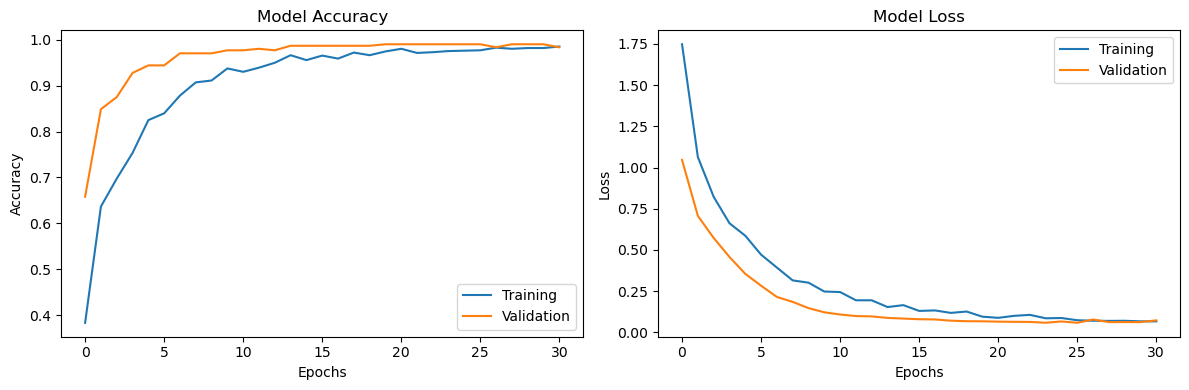

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

12/12 [==============================] - 0s 1ms/step

Classification Report:
                 precision    recall  f1-score   support

             TV       1.00      1.00      1.00        31
   baby_monitor       1.00      1.00      1.00        36
         lights       0.97      1.00      0.99        34
  motion_sensor       1.00      0.98      0.99        41
security_camera       1.00      1.00      1.00        43
 smoke_detector       1.00      1.00      1.00        40
         socket       1.00      1.00      1.00        36
     thermostat       0.96      0.96      0.96        49
          watch       0.96      0.96      0.96        48
   water_sensor       1.00      1.00      1.00        22

       accuracy                           0.99       380
      macro avg       0.99      0.99      0.99       380
   weighted avg       0.99      0.99      0.99       380



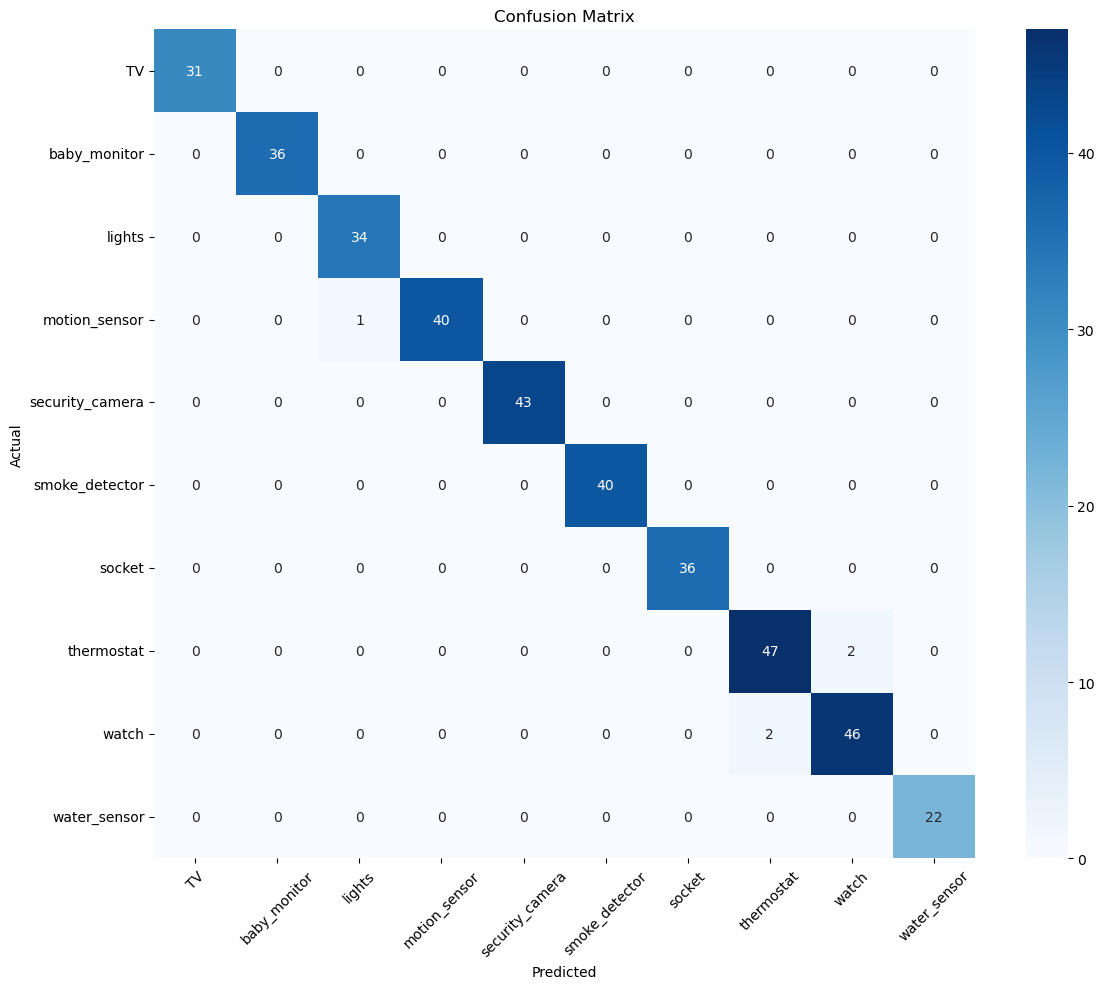

In [11]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=onehot_encoder.categories_[0]))

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=onehot_encoder.categories_[0],
            yticklabels=onehot_encoder.categories_[0])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
sample_idx = 5
probs = y_pred[sample_idx]
print(f"\nPrediction probabilities for sample {sample_idx}:")

for i, prob in enumerate(probs):
    print(f"Class {i} ({onehot_encoder.categories_[0][i]}): {prob:.4f}")

print(f"Predicted class: {onehot_encoder.categories_[0][np.argmax(probs)]}")
print(f"Actual class: {onehot_encoder.categories_[0][y_true_labels[sample_idx]]}")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


Prediction probabilities for sample 5:
Class 0 (TV): 0.0000
Class 1 (baby_monitor): 0.0000
Class 2 (lights): 0.0000
Class 3 (motion_sensor): 0.0002
Class 4 (security_camera): 0.0012
Class 5 (smoke_detector): 0.0000
Class 6 (socket): 0.0000
Class 7 (thermostat): 0.9771
Class 8 (watch): 0.0211
Class 9 (water_sensor): 0.0004
Predicted class: thermostat
Actual class: thermostat


In [13]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(onehot_encoder, "onehot_encoder.pkl")
joblib.dump(features_to_keep, "selected_features.pkl")


['selected_features.pkl']